# Companion notebook for "A Statistical Framework for Robust and Reproducible BioImage Analysis"

## 1. Introduction

With this notebook, you can apply the concepts discussed in the manuscript to your own data.

In contrast to the other two notebooks in this repository, this notebook assumes as a starting point a pandas Dataframe that can be loaded from a CSV file. In theory, this CSV file can be produced using any software capable of saving data in CSV format. However, there are certain requirements for this file in order for it to be compatible with this notebook. The data must be in the `tidy format` described by [Pylvänäinen et al (2025)](https://doi.org/10.1242/jcs.263801):

![Tidy Data Format](../assets/tidy_format.png)

It is assumed your CSV file will contain the following:

1. A column representing different treatments or conditions. One of these should be an untreated control.
2. A column representing a metric to be compared across all cells, all treatments and all experimental repeats
3. A column representing the labels for experimental repeats. This can be anything, as long as all cells from the same well or dish have the same unique label and each label identifies which experimental repeat the cell belongs to.

Here is a subset of the demo data used below to illustrate:

| YAPTAZ_Ratio | Well   | Treatment |
|--------------|--------|-----------|
| 0.8029917972 | 1A_I23 | LATS1     |
| 0.674030732  | 1A_B06 | MOCK      |
| 0.6528565152 | 1A_M23 | YAP       |
| 0.7262447915 | 2A_C13 | ARAP2     |
| 0.7509687808 | 2A_J23 | LATS1     |

Here, ``YAPTAZ_Ratio`` corresponds to the metric being compared, ``Treatment`` is the various experimental conditions being compared and ``Well`` is each experimental repeat, in the form of ``X_Y``, where ``X`` is the experiment number and ``Y`` is the well number (this format was used in case the same well number appeared in different experiments).

## 2. Import utility functions

The ``utility_functions`` script contains the defintions of many of the functions used below.

In [1]:


from utility_functions import *

## 3. Specify parameters

These parameters influence what will be plotted below and how those plots will appear:
* ``plt.rcParams['font.size']``: Font size for plots
* ``plt.rcParams['axes.linewidth']``: Line width for plots
* ``path_to_data``: The path to your CSV file where your data is stored. For the purposes of demonstration, we include demo data, similar to that described in the accompanying manuscript.
* ``metric_of_interest`` : Metric of interest to be plotted. This should correspond to one of the columns in the in put CSV file
* ``axis_label``: A more descriptive form of the ``metric_of_interest``, which will be used to label axes on the plots below
* ``treatment_col``: The heading of the column in your CSV file representing different treatments of conditions
* ``repeat_col``: The heading of the column in your CSV file representing different experimental repeats
* ``selected_repeat``: Choose a single experimental repeat to plot below
* ``control`` : The control condition that other treatments will be compared against

In [2]:
plt.rcParams['font.size'] = 26
plt.rcParams['axes.linewidth'] = 2
path_to_data = '../data_subsets/tidy_data/tidy_idr0028_data.csv'
metric_of_interest = 'YAPTAZ_Ratio'
axis_label = 'Relative Nuclear YAP/TAZ Localisation'
treatment_col = 'Treatment'
repeat_col = 'Well'
selected_repeat = '2A'
control = 'MOCK'

## 4. Load the CSV file

In [3]:
data = pd.read_csv(path_to_data)

## 5. Plot the data

### 5.1 Error in inter-quartile range versus sample size

This will generate a plot similar to that in Fig 2A in the accompanying manuscript. The following parameters can be modified:
* ``min_sample_size``: The minimum number of cells to sample - the smallest number on the x-axis
* ``max_sample_size``: The maximum number of cells to sample - the largest number on the x-axis
* ``step_size``: The sample size is iteratively increased by this number of cells - the gap between data points on the x-axis
* ``iterations``: The number of times a sample of each size is randomly drawn from the input data. Increasing this number will increase the time it takes the function to run, but it also increases the accuracy of the results.

Processing:   0%|          | 0/4900 [00:00<?, ?it/s]

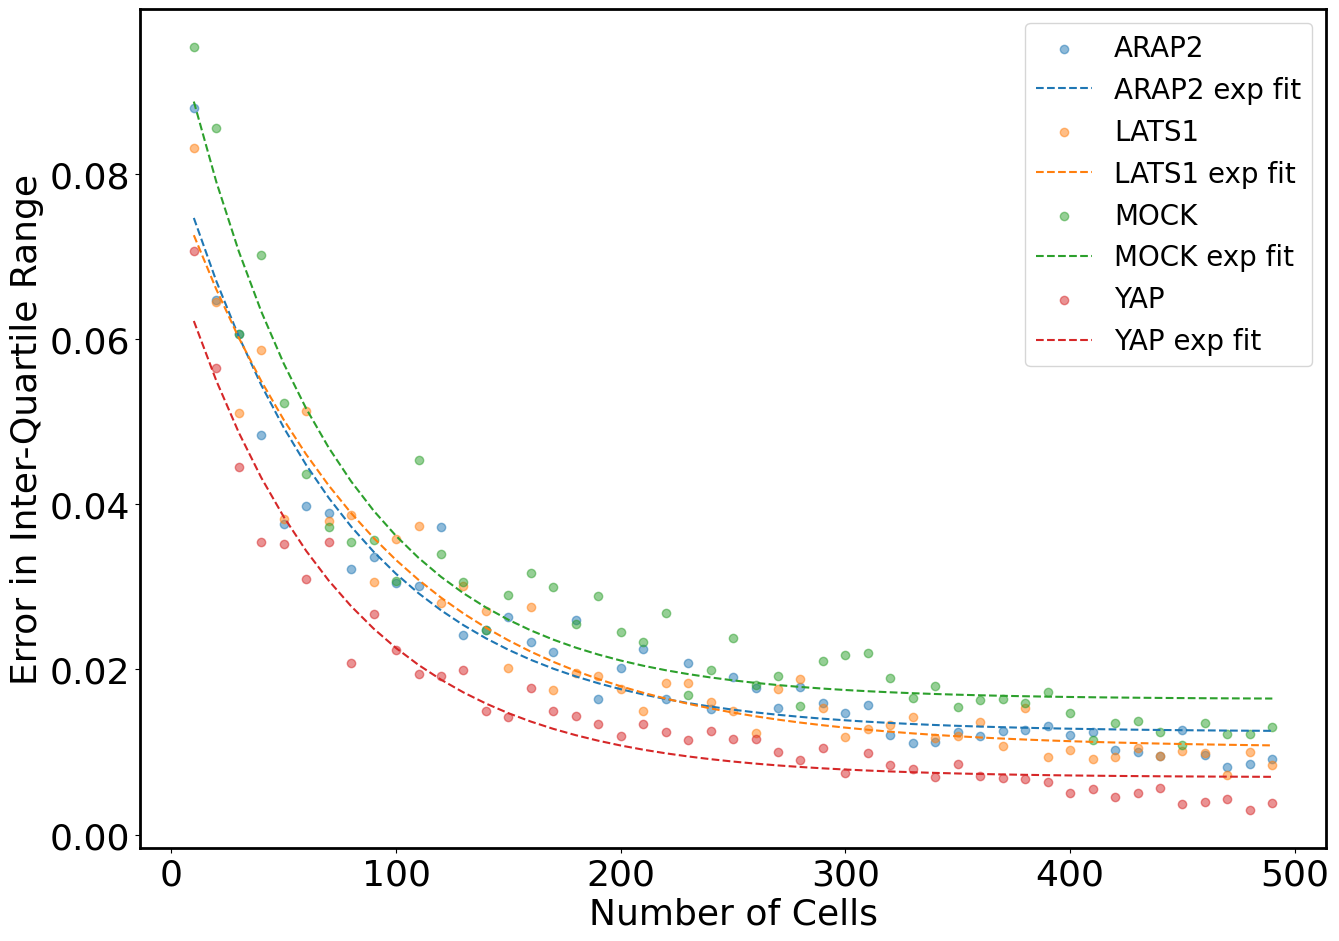

In [4]:
min_sample_size = 10
max_sample_size = 500
step_size = 10
iterations = 100
y_label = 'Error in Inter-Quartile Range'

plot_iqr_v_sample_size([*range(min_sample_size, max_sample_size, step_size)], iterations,
                       data[data['Well'].str.contains(selected_repeat)], treatment_col, metric_of_interest, y_label)

### 5.2 Error in inter-quartile range versus sample size

This will generate plots similar to Fig 2B-H in the accompanying manuscript, illustrating how the statistical properties of samples of your control cells change as the sample size is increased

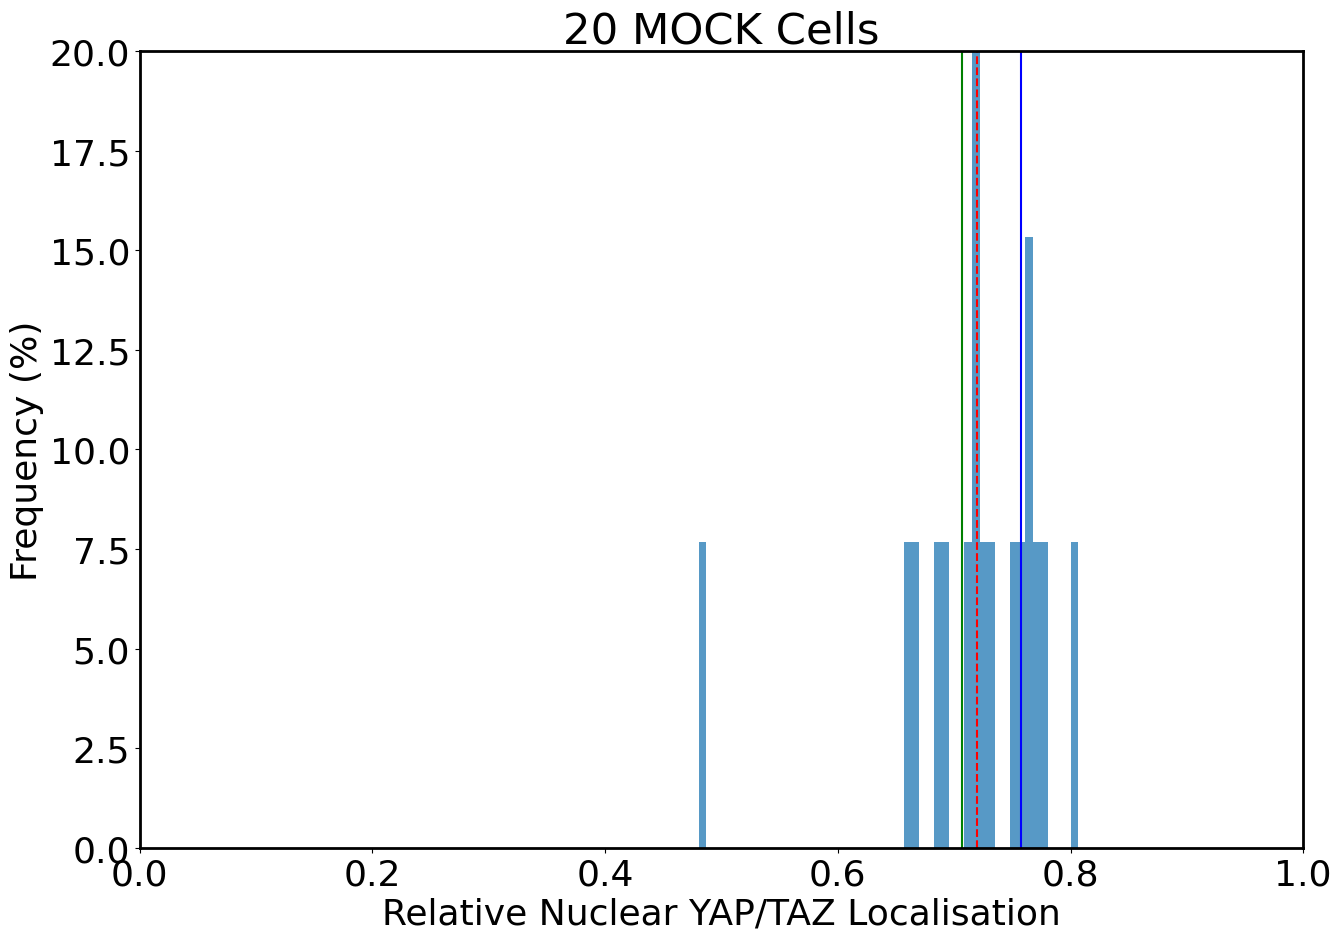

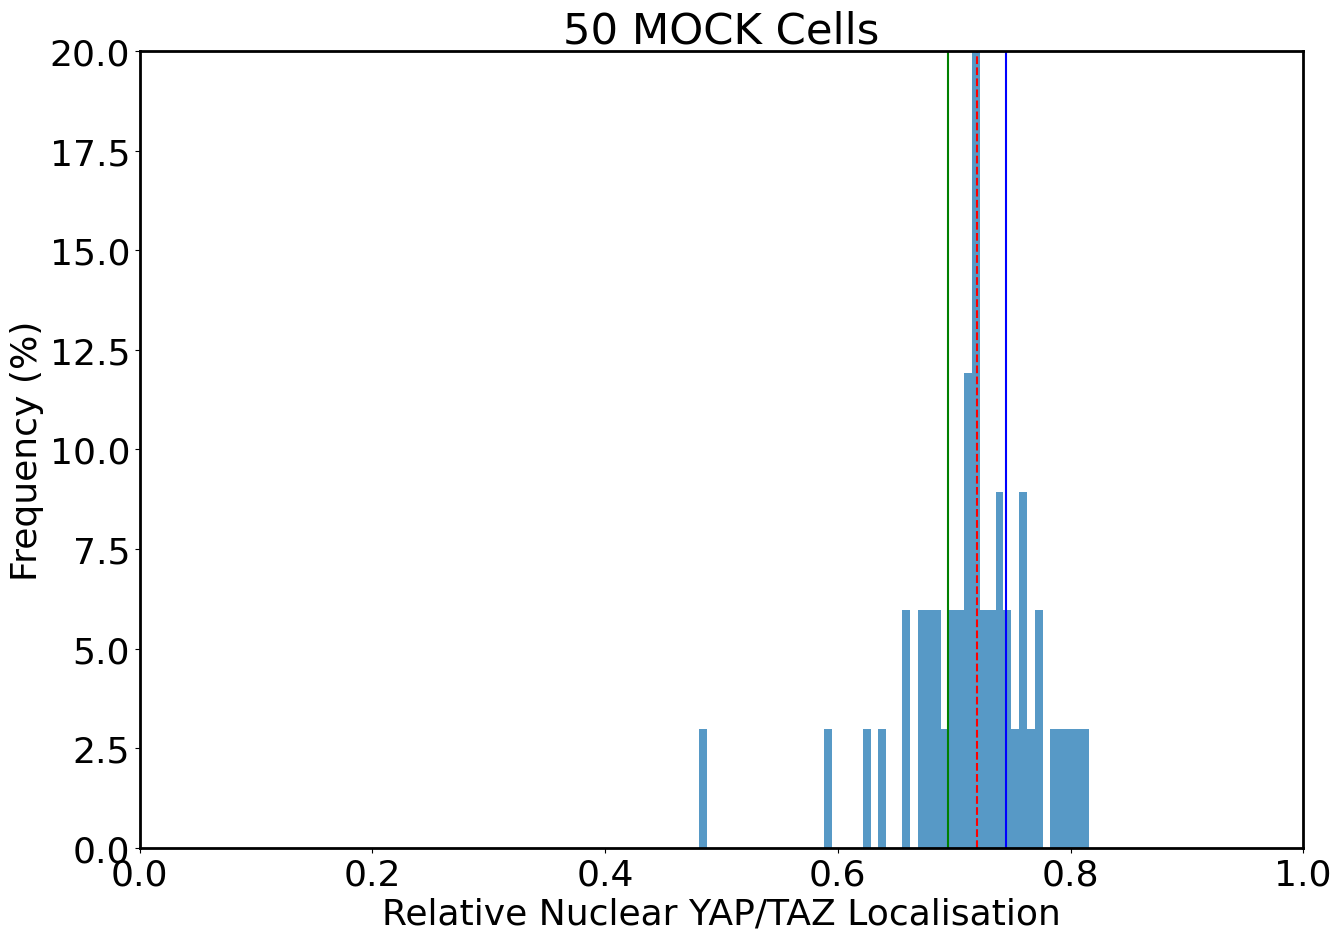

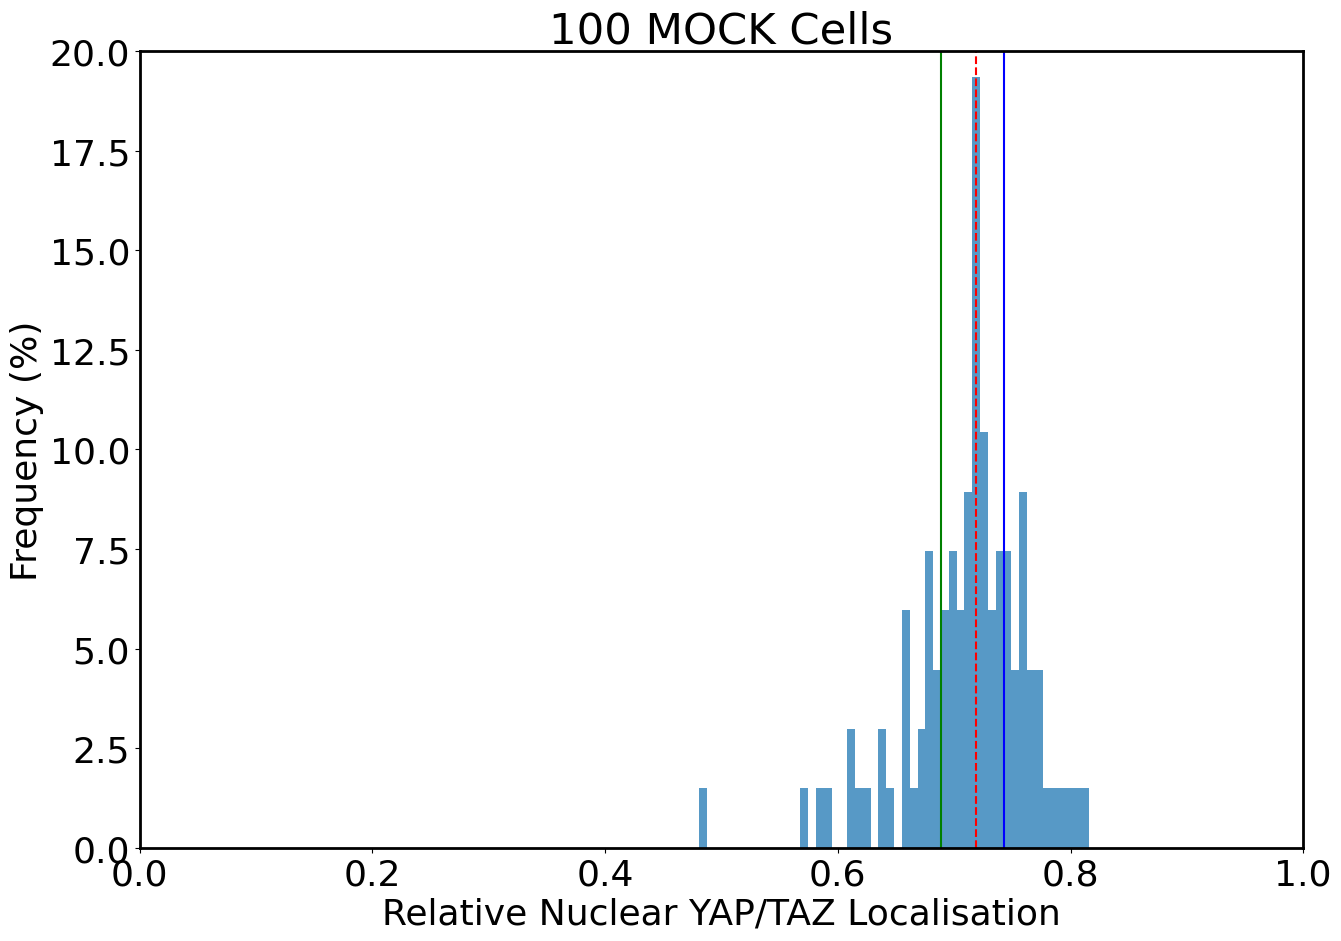

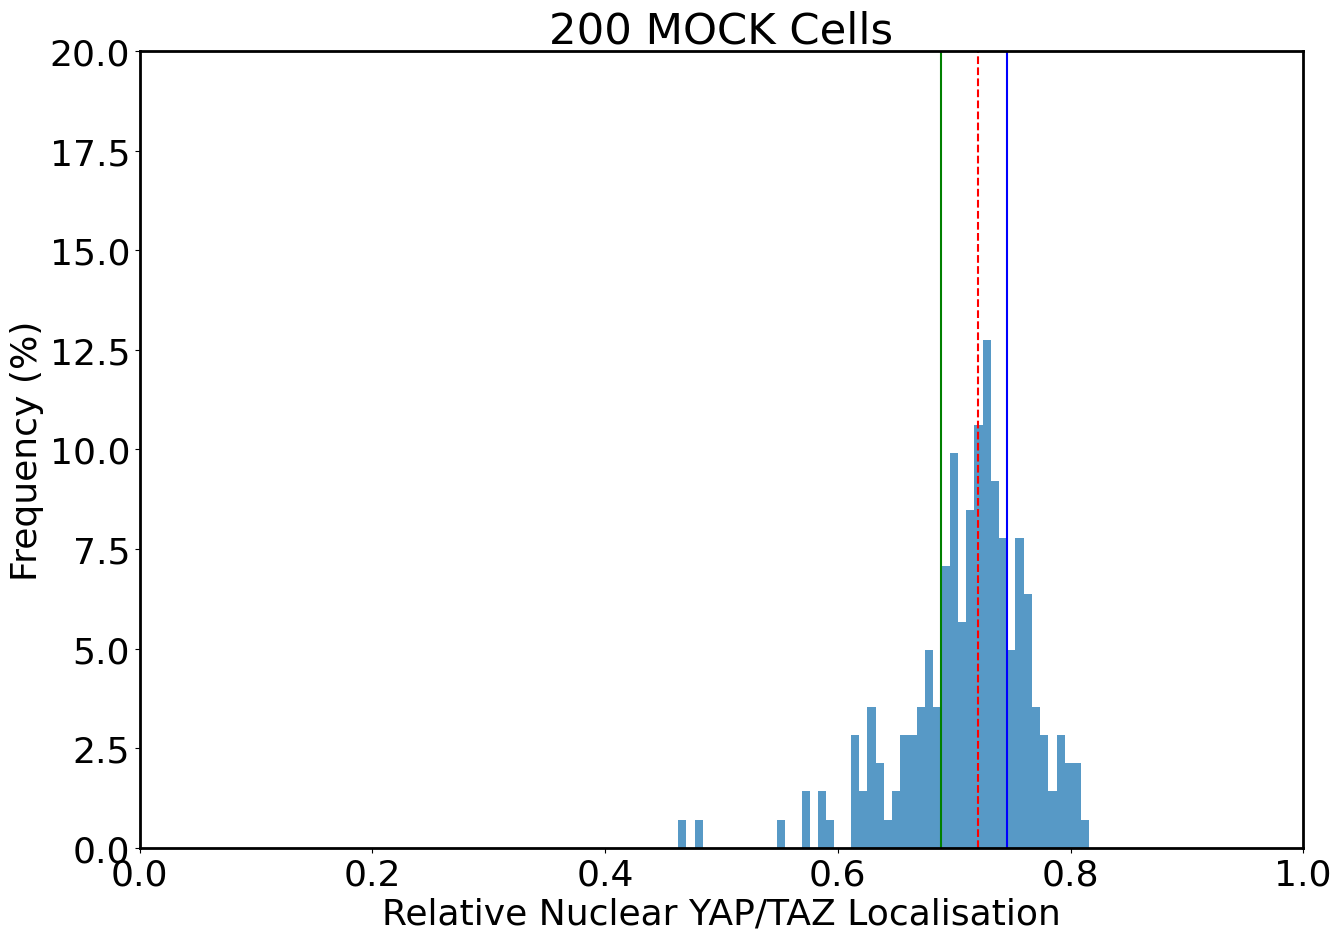

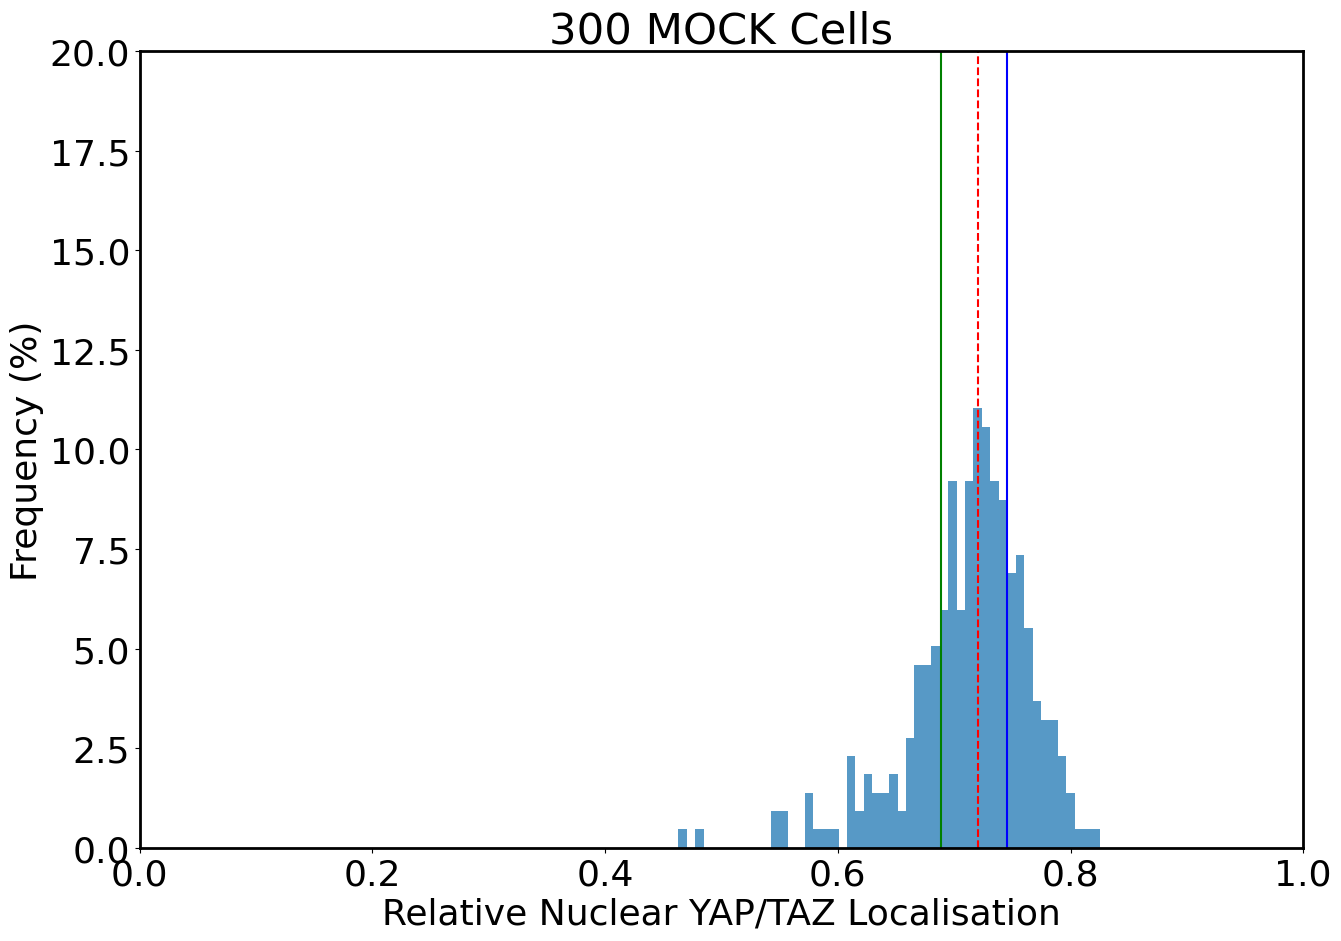

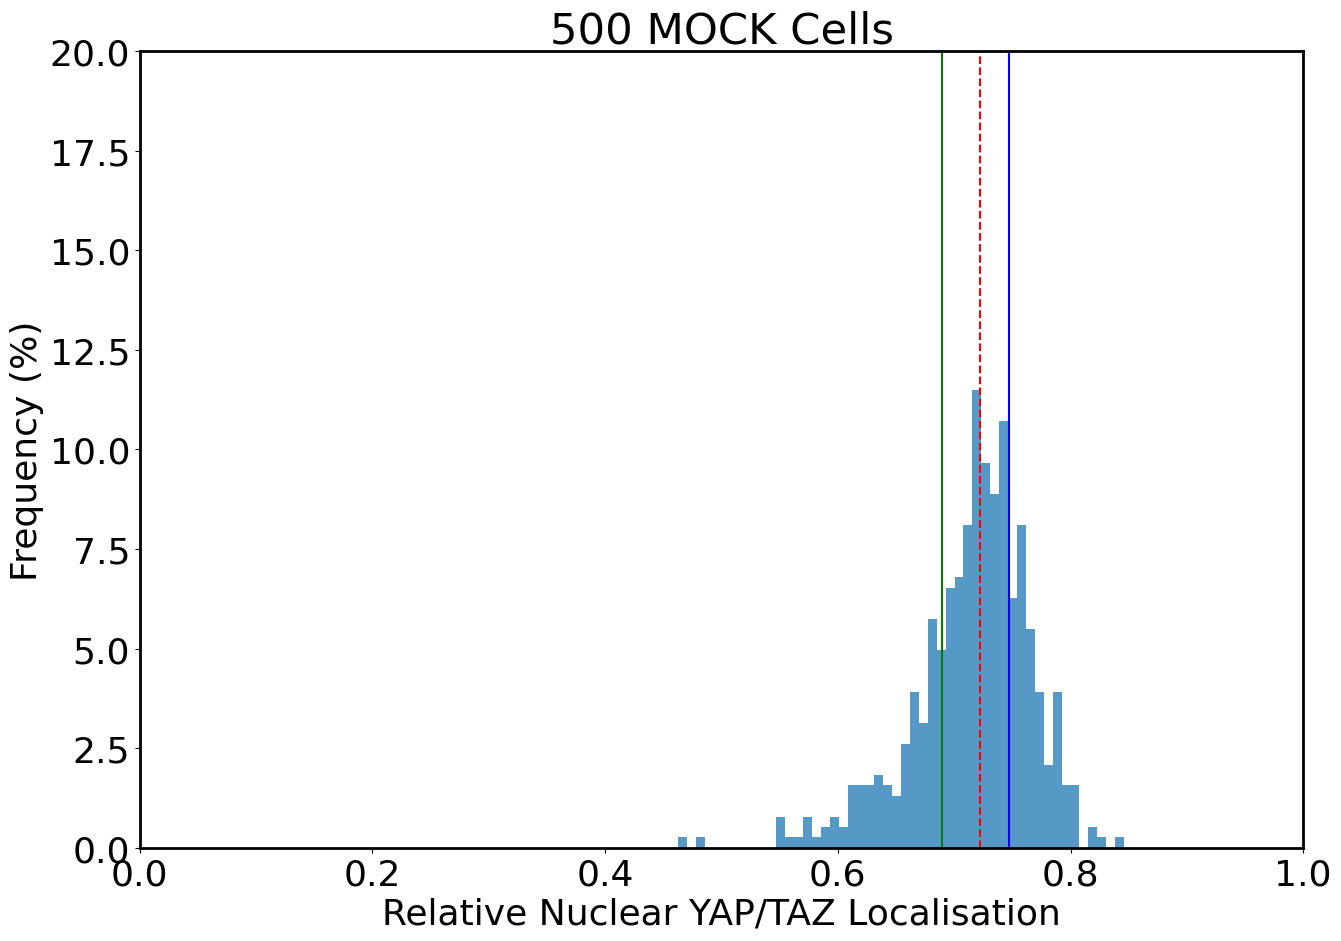

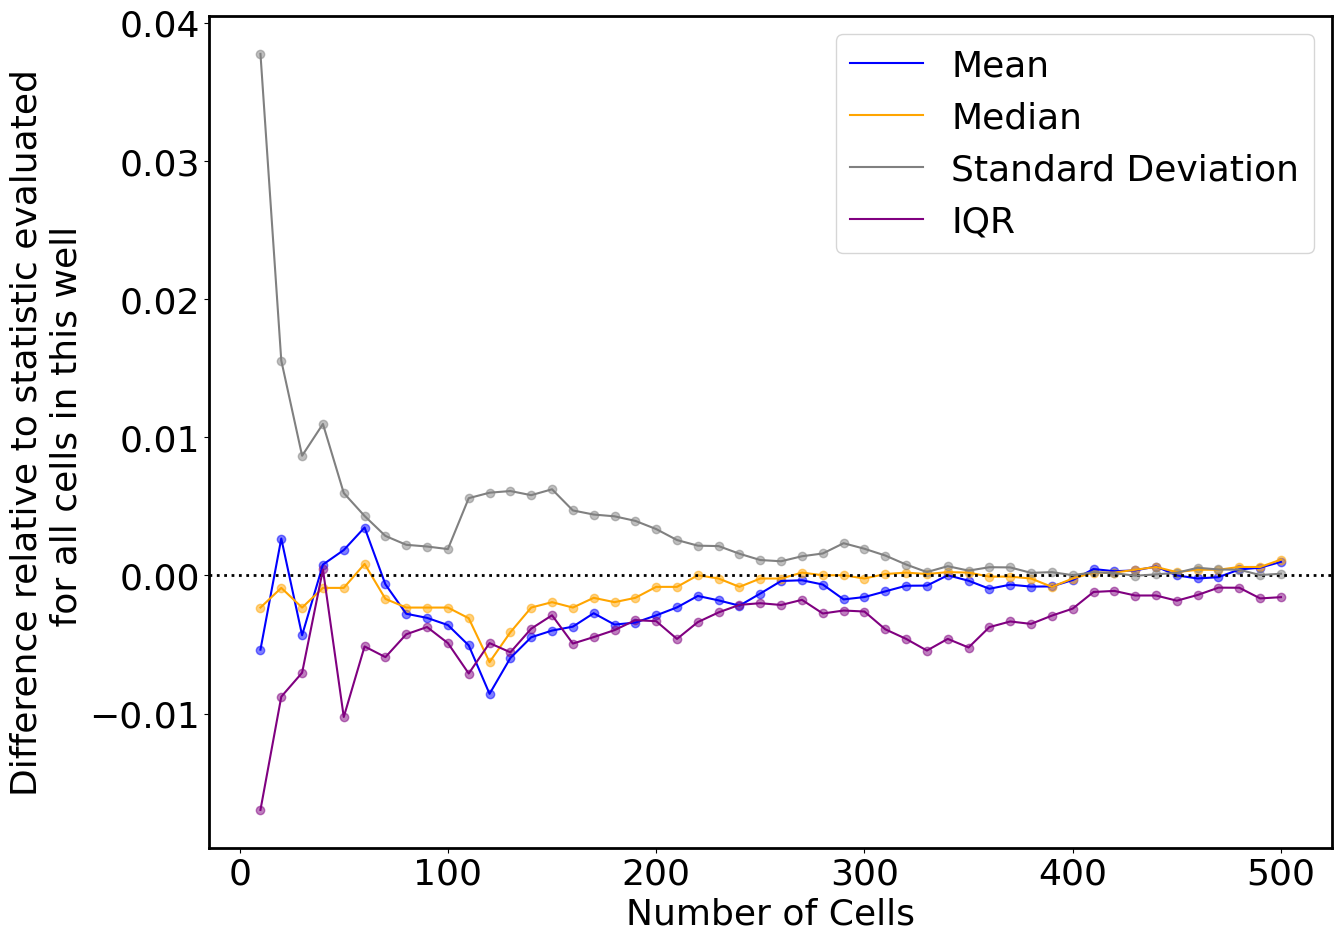

In [5]:
plot_cumulative_histogram_samples(data[data['Well'].str.contains(selected_repeat)], metric_of_interest, treatment_col,
                                  control, axis_label)

### 5.3 Swarm and boxplots of metric of interest for different sample sizes

This will generate plots similar to Fig 3A-F in the accompanying manuscript, illustrating how the overall result of an experiment changes for different cell sample sizes. The following parameters can be modified:
* ``point_size``: Size of points in swarm plots. Large values may cause errors if there are a lot of points to plot.
* ``random_seed``: Starting value used to initialise a pseudorandom number generator - see [here](https://en.wikipedia.org/wiki/Random_seed). Essentially, this ensures the code draws the same ''random'' samples every time it is run.
* ``sample_sizes``: The different numbers of cells to randomly sample and plot for each condition
* ``iterations``: Number of plots to produce for each sample size


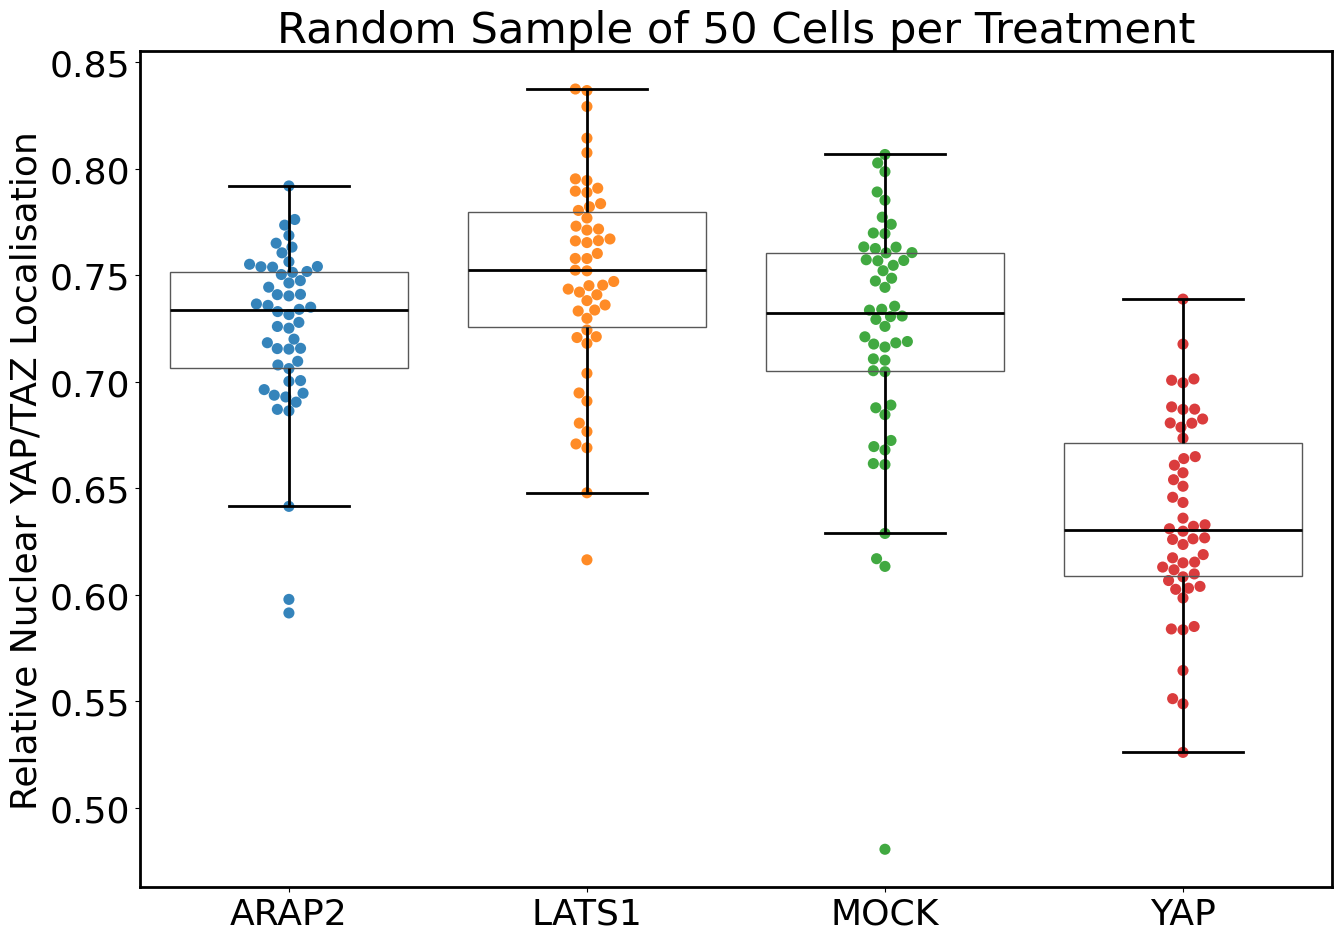

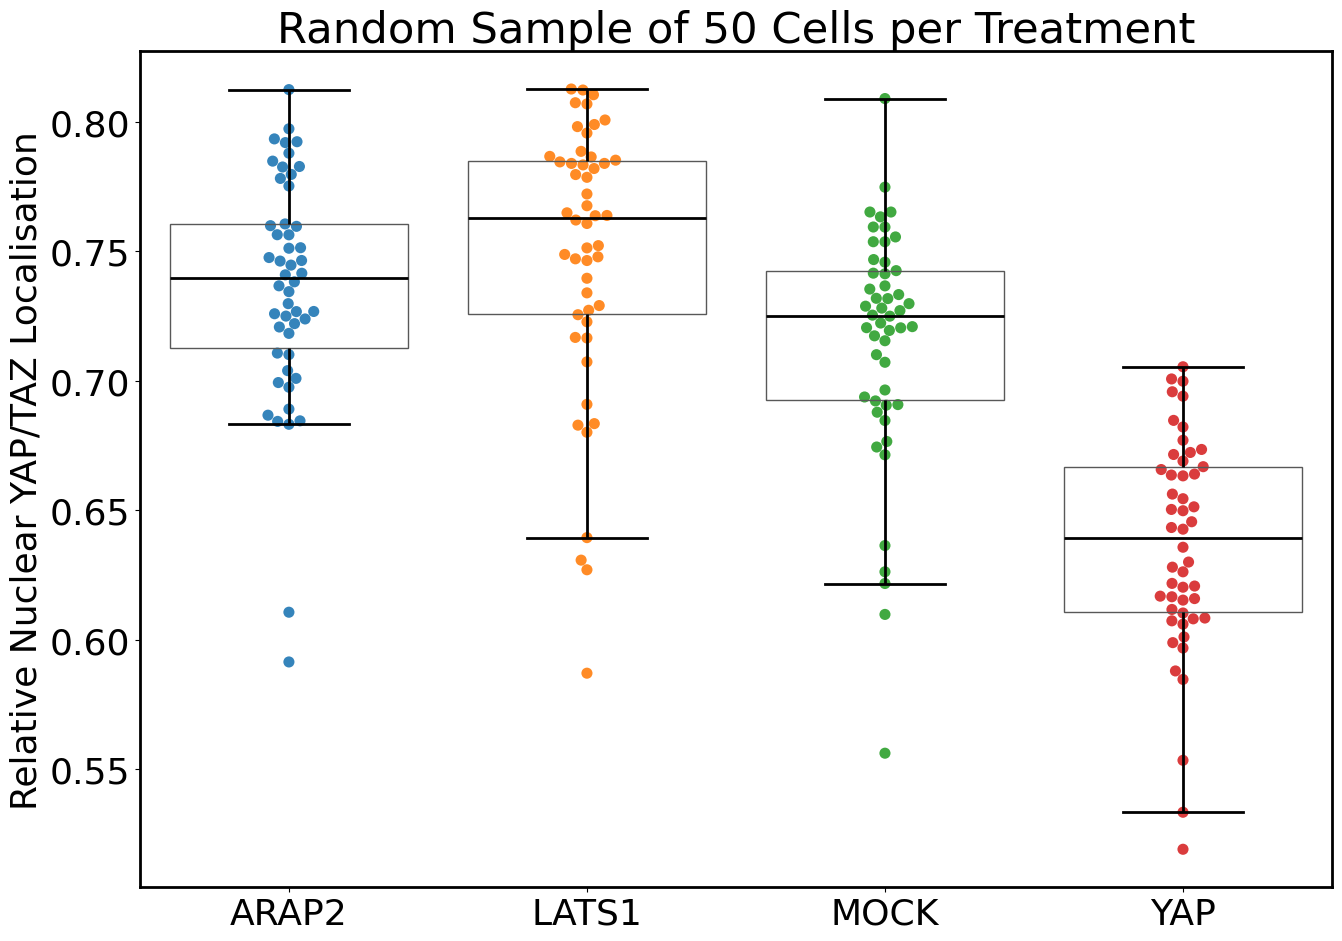

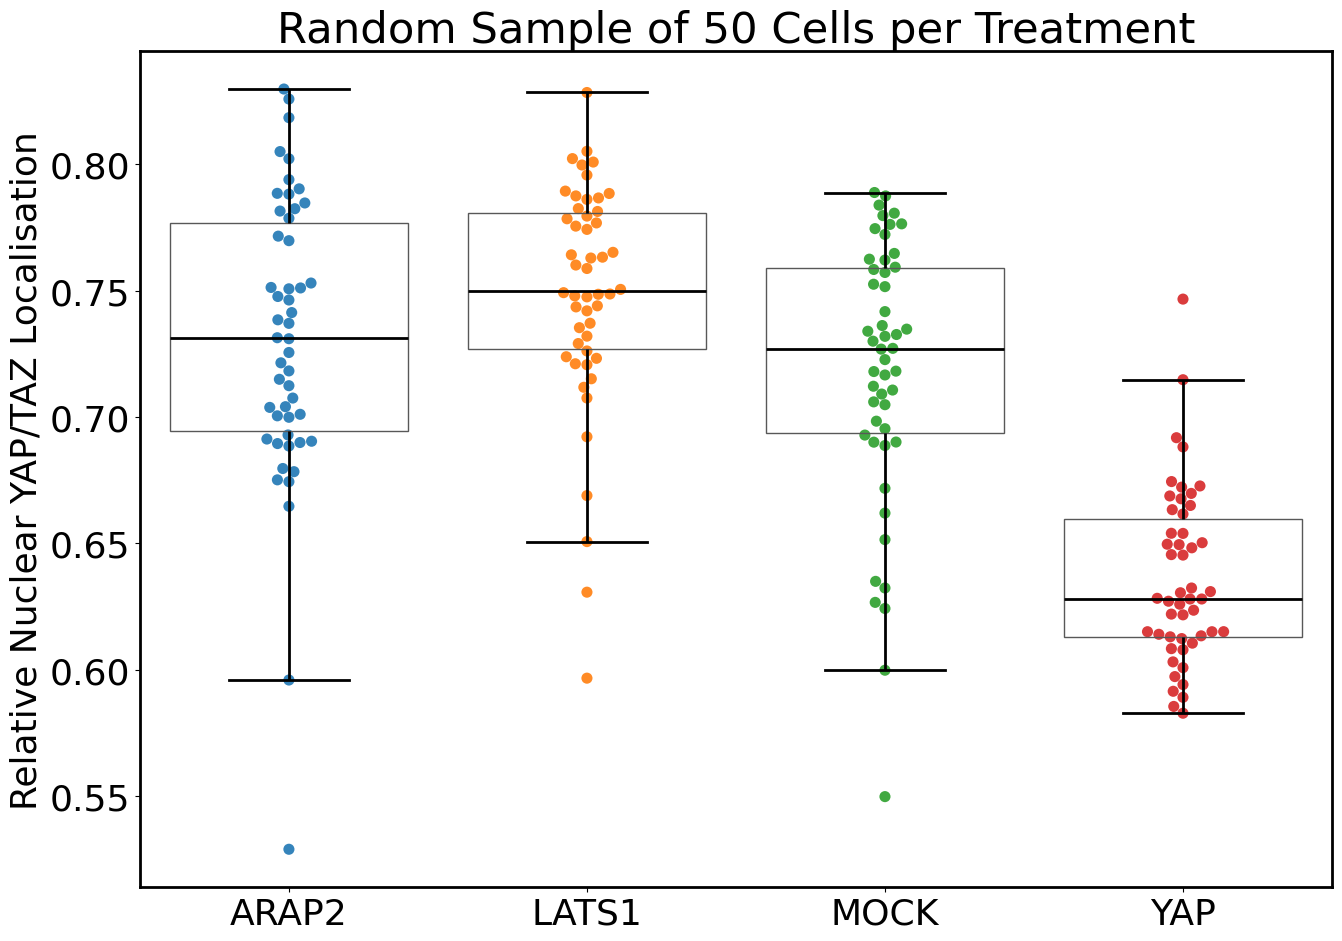

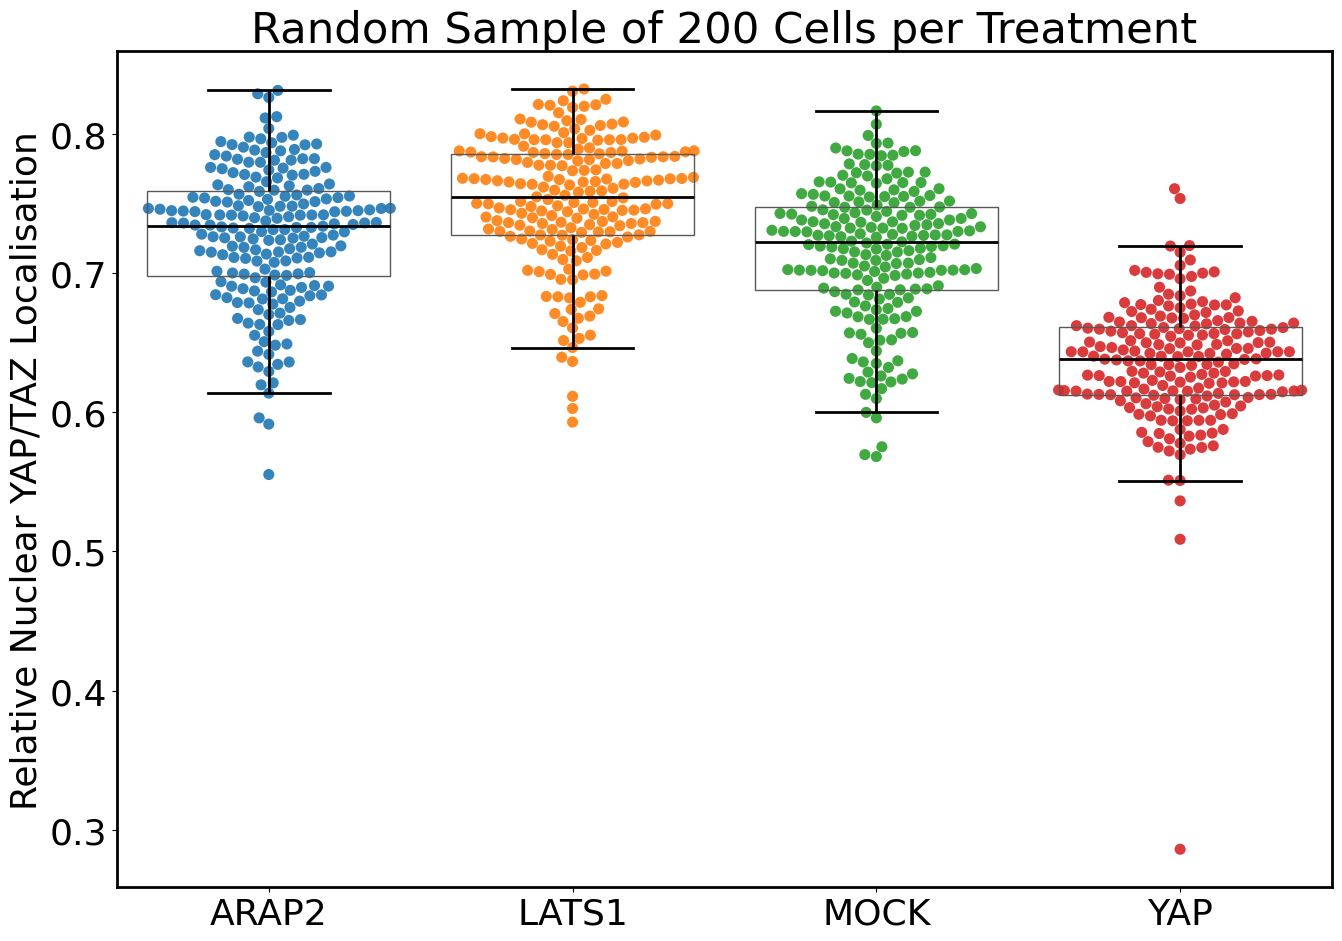

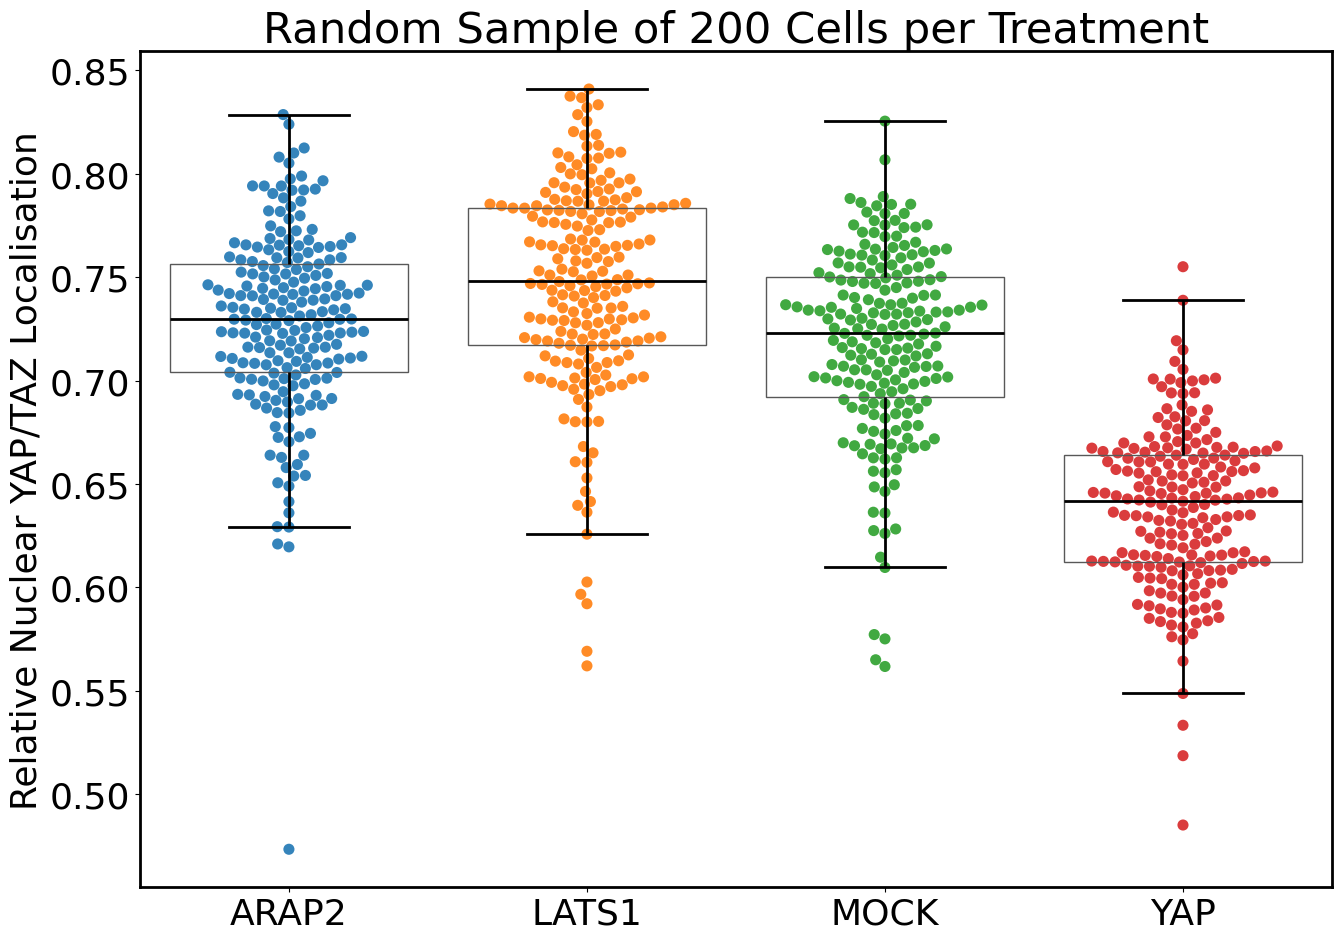

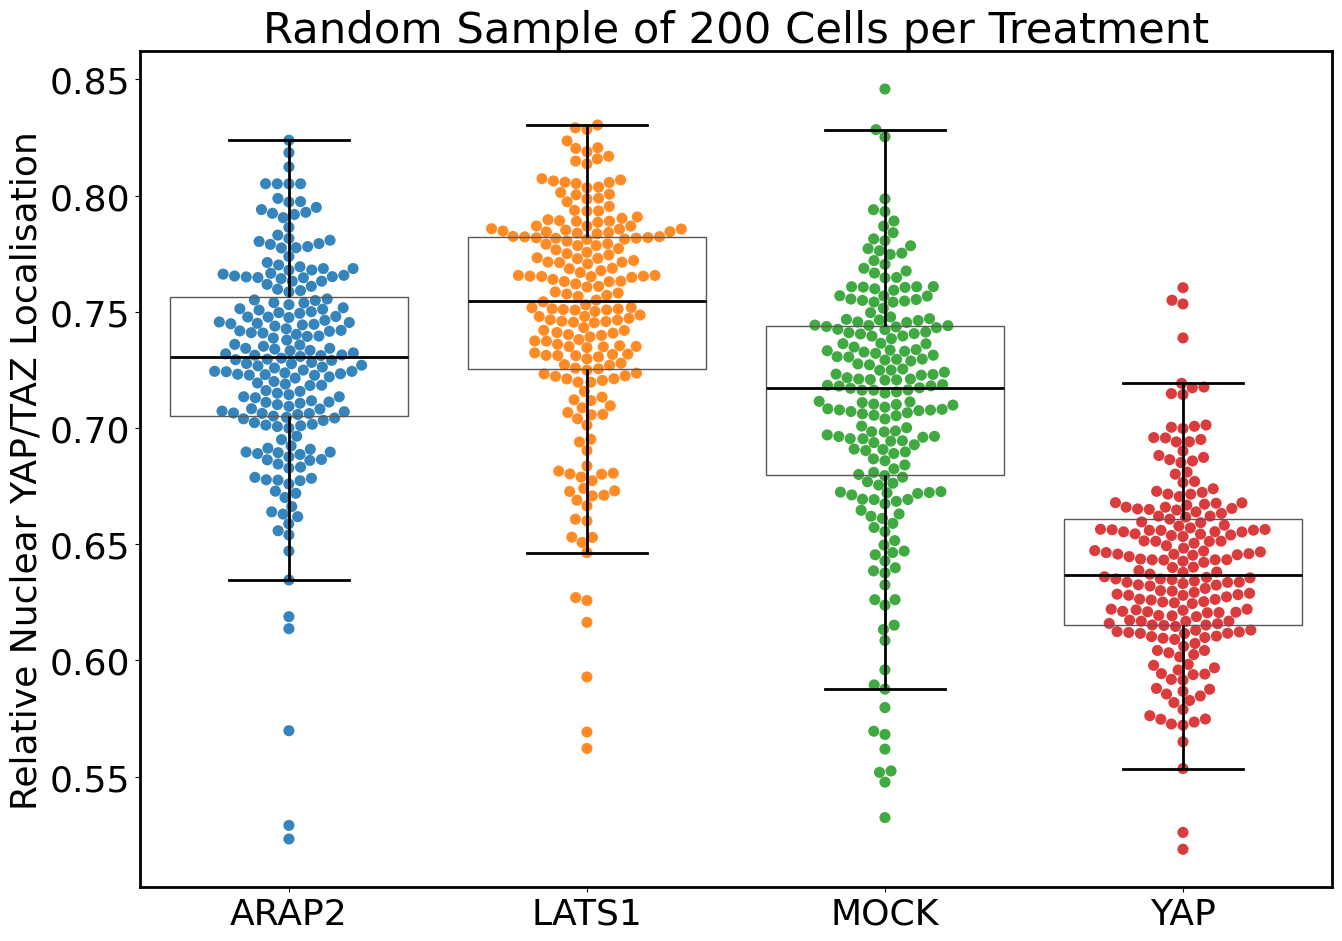

In [6]:
point_size = 8
random_seed = 42
sample_sizes = [50, 200]
iterations = 3

for s in sample_sizes:
    for i in range(iterations):
        generate_swarmplot(np.unique(data[treatment_col]), data[data['Well'].str.contains(selected_repeat)], None,
                           treatment_col, metric_of_interest, axis_label,
                           point_size=point_size, random_seed=random_seed, sample_size=s,
                           title=f'Random Sample of {s} Cells per Treatment')
        random_seed = random_seed + 1

### 5.4 Effect sizes for different sample sizes

This will generate plots similar to Fig 3G-I in the accompanying manuscript, illustrating how the overall result of an experiment changes for different cell sample sizes. The following parameters can be modified:
* ``min_sample_size``: The minimum number of cells to sample - the smallest number on the x-axis
* ``max_sample_size``: The maximum number of cells to sample - the largest number on the x-axis
* ``step_size``: The sample size is iteratively increased by this number of cells - the gap between data points on the x-axis
* ``iterations``: The number of times a sample of each size is randomly drawn from the input data. Increasing this number will increase the time it takes the function to run, but it also increases the accuracy of the results.


Processing:   0%|          | 0/4900 [00:00<?, ?it/s]

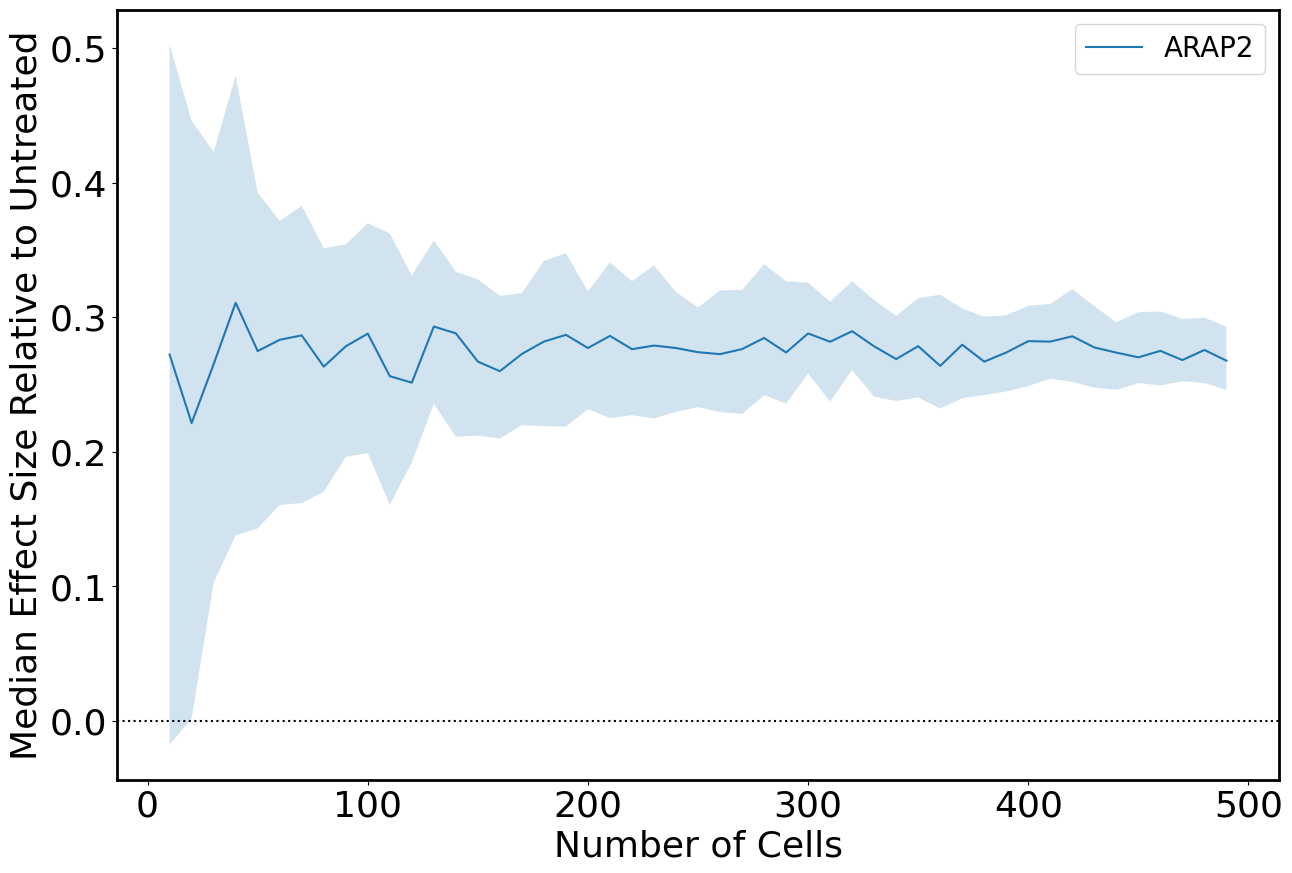

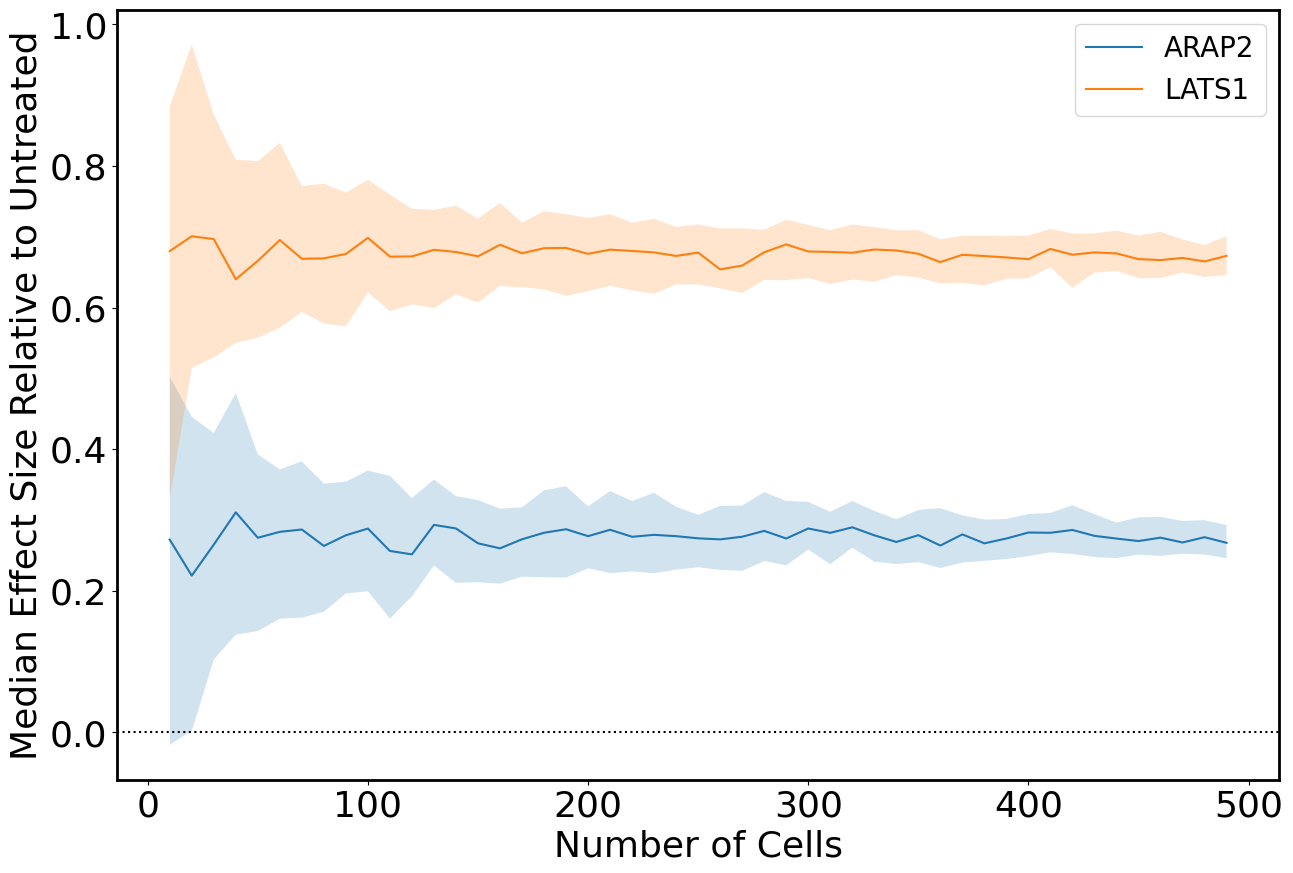

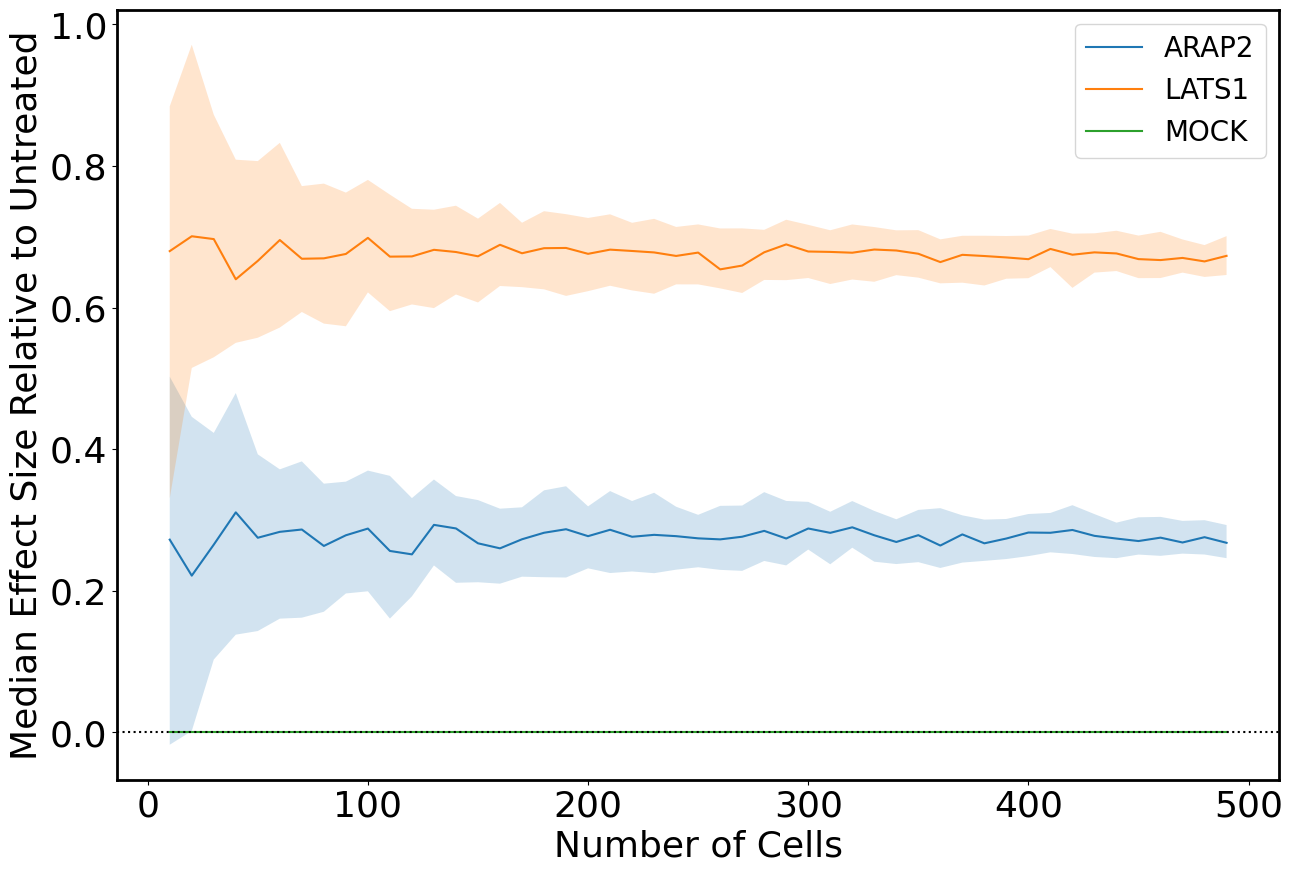

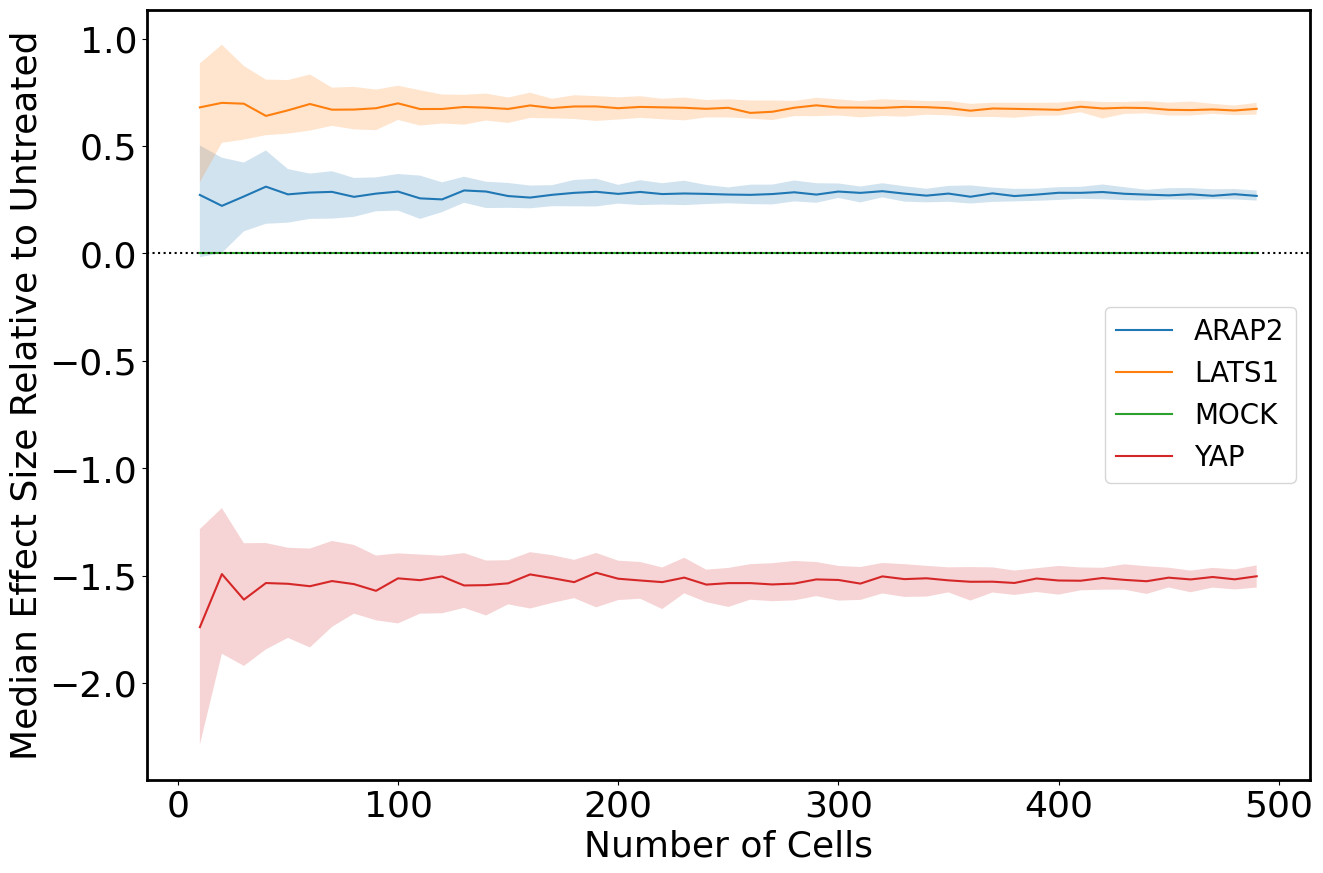

In [7]:
min_sample_size = 10
max_sample_size = 500
step_size = 10
iterations = 100
y_label = 'Median Effect Size Relative to Untreated'

plot_effect_size_v_sample_size([*range(min_sample_size, max_sample_size, step_size)], iterations,
                               data[data['Well'].str.contains(selected_repeat)], treatment_col, metric_of_interest,
                               y_label, np.unique(data[treatment_col]), control)

### 5.5 Generate Superplot

This will generate a "super-plot" of your data, as described by [Lord et al (2020)](https://doi.org/10.1083/jcb.202001064) similar to that in Figure 4 of the accompanying manuscript.

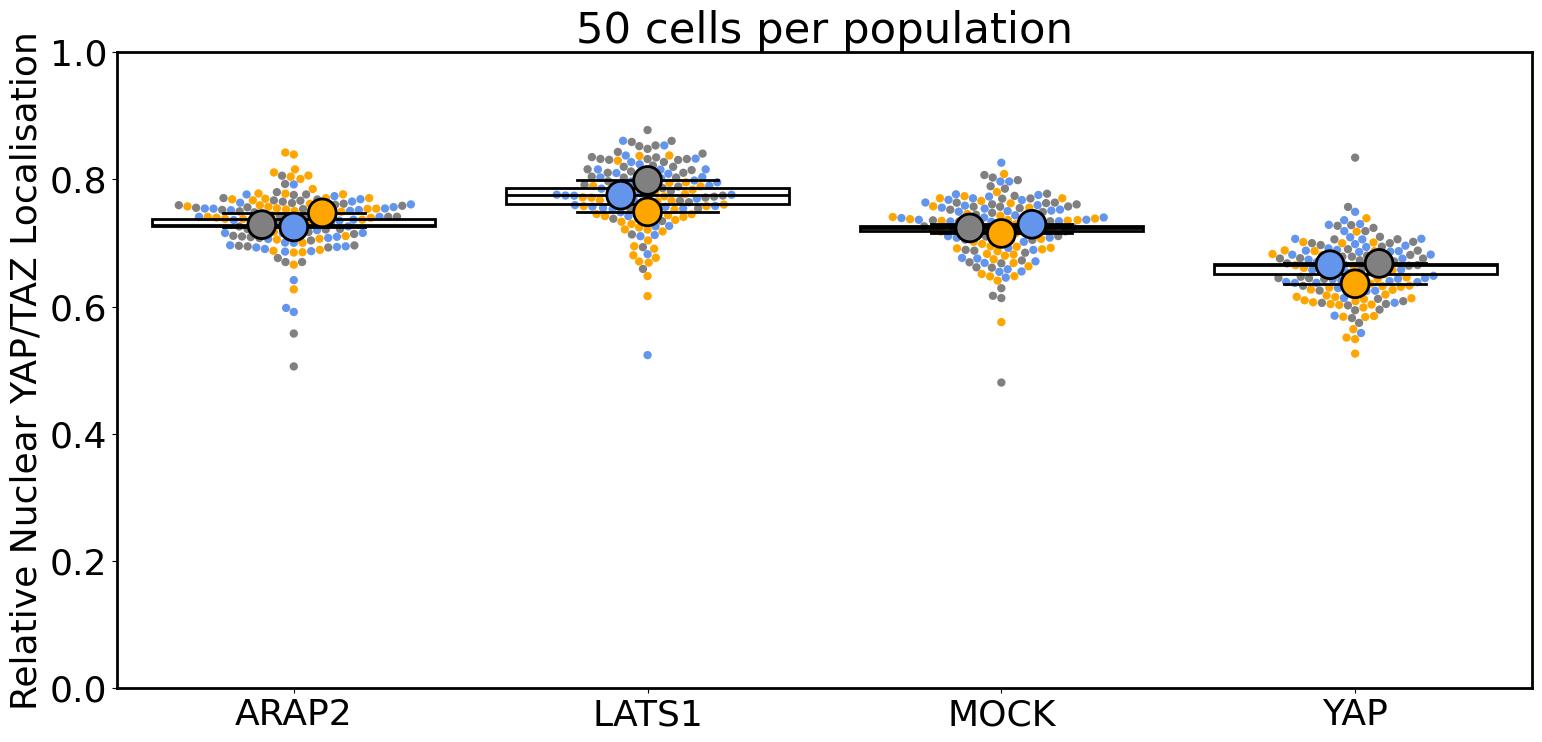

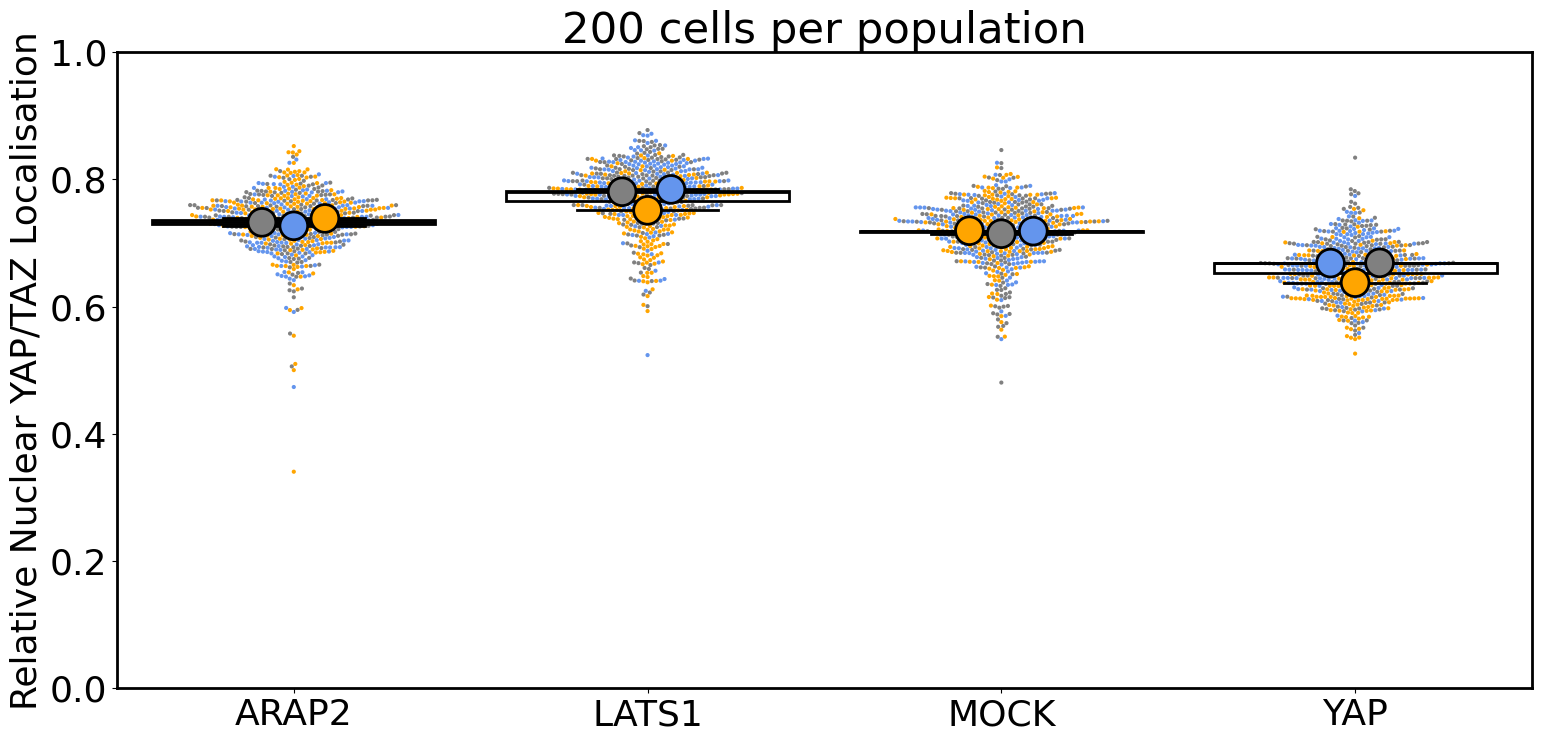

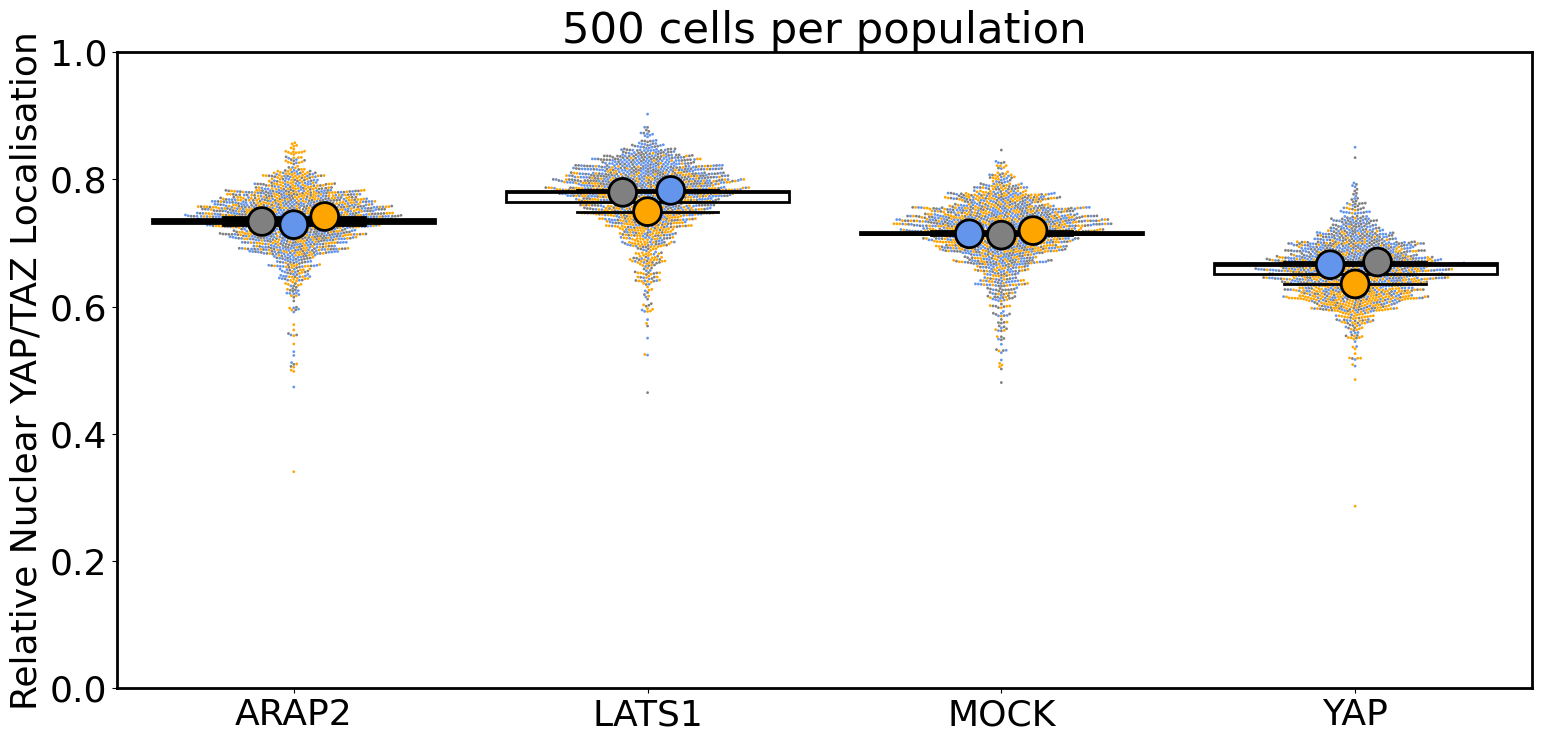

In [8]:

point_size = {50: 6, 200: 3, 500: 2}
for s in [50, 200, 500]:
    generate_superplot(np.unique(data[treatment_col]), np.unique(data[treatment_col]), data, treatment_col,
                       repeat_col, metric_of_interest, axis_label, sample_size=s, point_size=point_size[s])
